In [ ]:
import pandas as pd

# Correct file path (IMPORTANT)
file_path ="letter-recognition.data"

columns = ["letter"] + [f"feature_{i}" for i in range(1,17)]

data = pd.read_csv(file_path, names=columns)

print(data.head())
print("Shape:", data.shape)

  letter  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      T          2          8          3          5          1          8   
1      I          5         12          3          7          2         10   
2      D          4         11          6          8          6         10   
3      N          7         11          6          6          3          5   
4      G          2          1          3          1          1          8   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0         13          0          6           6          10           8   
1          5          5          4          13           3           9   
2          6          2          6          10           3           7   
3          9          4          6           4           4          10   
4          6          6          6           6           5           9   

   feature_13  feature_14  feature_15  feature_16  
0           0           8         

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode target (A-Z → 0-25)
le = LabelEncoder()
y = le.fit_transform(data["letter"])

# Features
X = data.drop("letter", axis=1)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Classes:", len(np.unique(y)))

Classes: 26


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(16,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(26, activation='softmax')  # 26 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5348 - loss: 1.6593 - val_accuracy: 0.7188 - val_loss: 0.9450
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7659 - loss: 0.7662 - val_accuracy: 0.7844 - val_loss: 0.7078
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8213 - loss: 0.5840 - val_accuracy: 0.8303 - val_loss: 0.5544
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 0.4791 - val_accuracy: 0.8612 - val_loss: 0.4686
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8762 - loss: 0.4070 - val_accuracy: 0.8763 - val_loss: 0.4022
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8952 - loss: 0.3514 - val_accuracy: 0.8794 - val_loss: 0.3849
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9059 - loss: 0.3118 - val_accuracy: 0.8900 - val_loss: 0.3541
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9170 - loss: 0.2803 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9383 - loss: 0.1887
Test Accuracy: 0.9382500052452087


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert back to letters
pred_letters = le.inverse_transform(y_pred_classes)
actual_letters = le.inverse_transform(y_test)

for i in range(5):
    print(f"Actual: {actual_letters[i]}, Predicted: {pred_letters[i]}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Actual: T, Predicted: Z
Actual: L, Predicted: L
Actual: A, Predicted: A
Actual: E, Predicted: E
Actual: Q, Predicted: Q


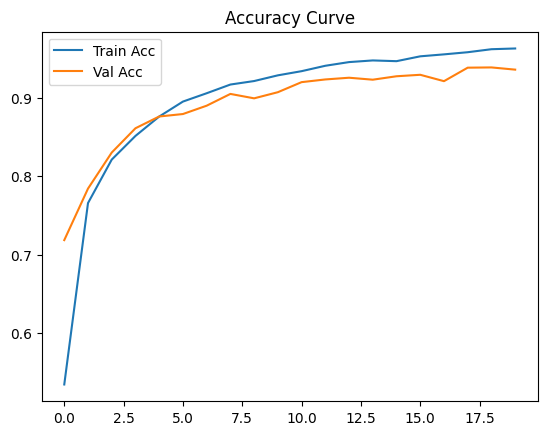

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

# 9. Print ONLY accuracy
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9382500052452087
